# 📑 Решение тестового задания на стажировку в Avito
**Задача:** Прогнозирование конверсии лидов на основе исторических данных и логов активности пользователей.

**Автор:** Никита Гарькуша

---

## 🎯 Почему для решения был выбран CatBoost?

Для реализации этого решения в качестве основного алгоритма был выбран **CatBoostClassifier** от Яндекса по нескольким критически важным причинам:

1. **Идеальная работа с категориальными признаками из коробки**
2. **Устойчивость к аномалиям и форме распределений:** В датасете присутствуют сильно скошенные признаки (например, логарифмы цен, интенсивность свайпов). Бустинг над деревьями решений инвариантен к монотонным преобразованиям и масштабу фич, поэтому форма распределений и выбросы не ломают сплиты в узлах.
3. **Мощные встроенные дефолтные параметры:** Сильные базовые настройки позволяют быстро построить надежный бейзлайн и сфокусировать основное время на Feature Engineering, а не на слепом переборе сеток параметров.
4. **Нативный инструментарий для анализа данных:** Встроенные методы оценки важности признаков (`feature_importances_`) и встроенный рандом-сёрч позволяют проводить итеративный отбор фич прямо внутри экосистемы модели, экономя время на валидацию.

---

## 🗺️ Пайплайн исследования (Структура ноутбука)

Решение выстроено в виде 9 последовательных шагов, отражающих итеративный процесс улучшения качества модели:

*   **Шаг 1. Первичный EDA категорий:** Анализ распределения частот и мощностей категориальных признаков для понимания структуры данных.
*   **Шаг 2. Валидация и Баланс классов:** Разбиение данных на обучающую (`train`) и валидационную (`val`) выборки. Проверка стратификации — баланс классов в обеих выборках.
*   **Шаг 3. Реализация кастомной метрики:** Написание функции `Daily_ap` для локального расчета целевой посуточной метрики Average Precision.
*   **Шаг 4. Построение Baseline модели:** Обучение первого CatBoostClassifier на исходных статических агрегатах. Локальный скор: **Daily AP = 0.519**. Извлечение важности признаков для фильтрации шума.
*   **Шаг 5. Первичный Feature Engineering:** Точечная проработка ТОП-15 самых важных фич по версии модели, изучение природы и структуры пропусков (NaN) в этих колонках.
*   **Шаг 6. Обучение второй итерации:** Оценка модели после первичного FE. Метрика Daily AP осталась стабильной, что указало на необходимость привлечения более глубоких поведенческих сигналов.
*   **Шаг 7. Анализ динамики важности признаков:** Повторный аудит сплитов модели, подтвердивший, что часть созданных признаков успешно зашла в структуру деревьев.
*   **Шаг 8. Инжиниринг поведенческих логов (`events.csv`):** Разработка динамических фич из сырых логов (счетчики чатов, размах цен в сессиях, глубина и длительность активности). 
    > ⚠️ **Защита от Data Leakage:** Все исторические события жестко отфильтрованы по условию `event_ts < assignment_ts`. События из будущего отсечены.
    *   *Результат:* **Взлет Daily AP до 0.562, Precision до 0.731.**
*   **Шаг 9. Гиперпараметрический тюнинг:** Направленный поиск по сетке параметров регуляризации, бэггинга и глубины. Подбор более консервативной архитектуры (`depth: 5`, `l2_leaf_reg: 5`) позволил эффективнее сгладить шум в логах.
    *   *Результат:* **Пиковый скор решения — Daily AP вырос до 0.571, общий AP до 0.579.** Данная конфигурация зафиксирована как финальная.

In [64]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, precision_score
from src.preprocessing import train_val_split, features_split
from src.evaluate import daily_ap
from src.features import get_top_importance, event_features

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42)



RANDOM_STATE = 42


In [65]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")


## Анализ категориальных признаков

Index(['lead_id', 'user_id', 'assignment_ts', 'assignment_date', 'lead_source',
       'call_center', 'region', 'car_segment', 'lead_channel',
       'user_tenure_bucket', 'price_bucket'],
      dtype='str') 11


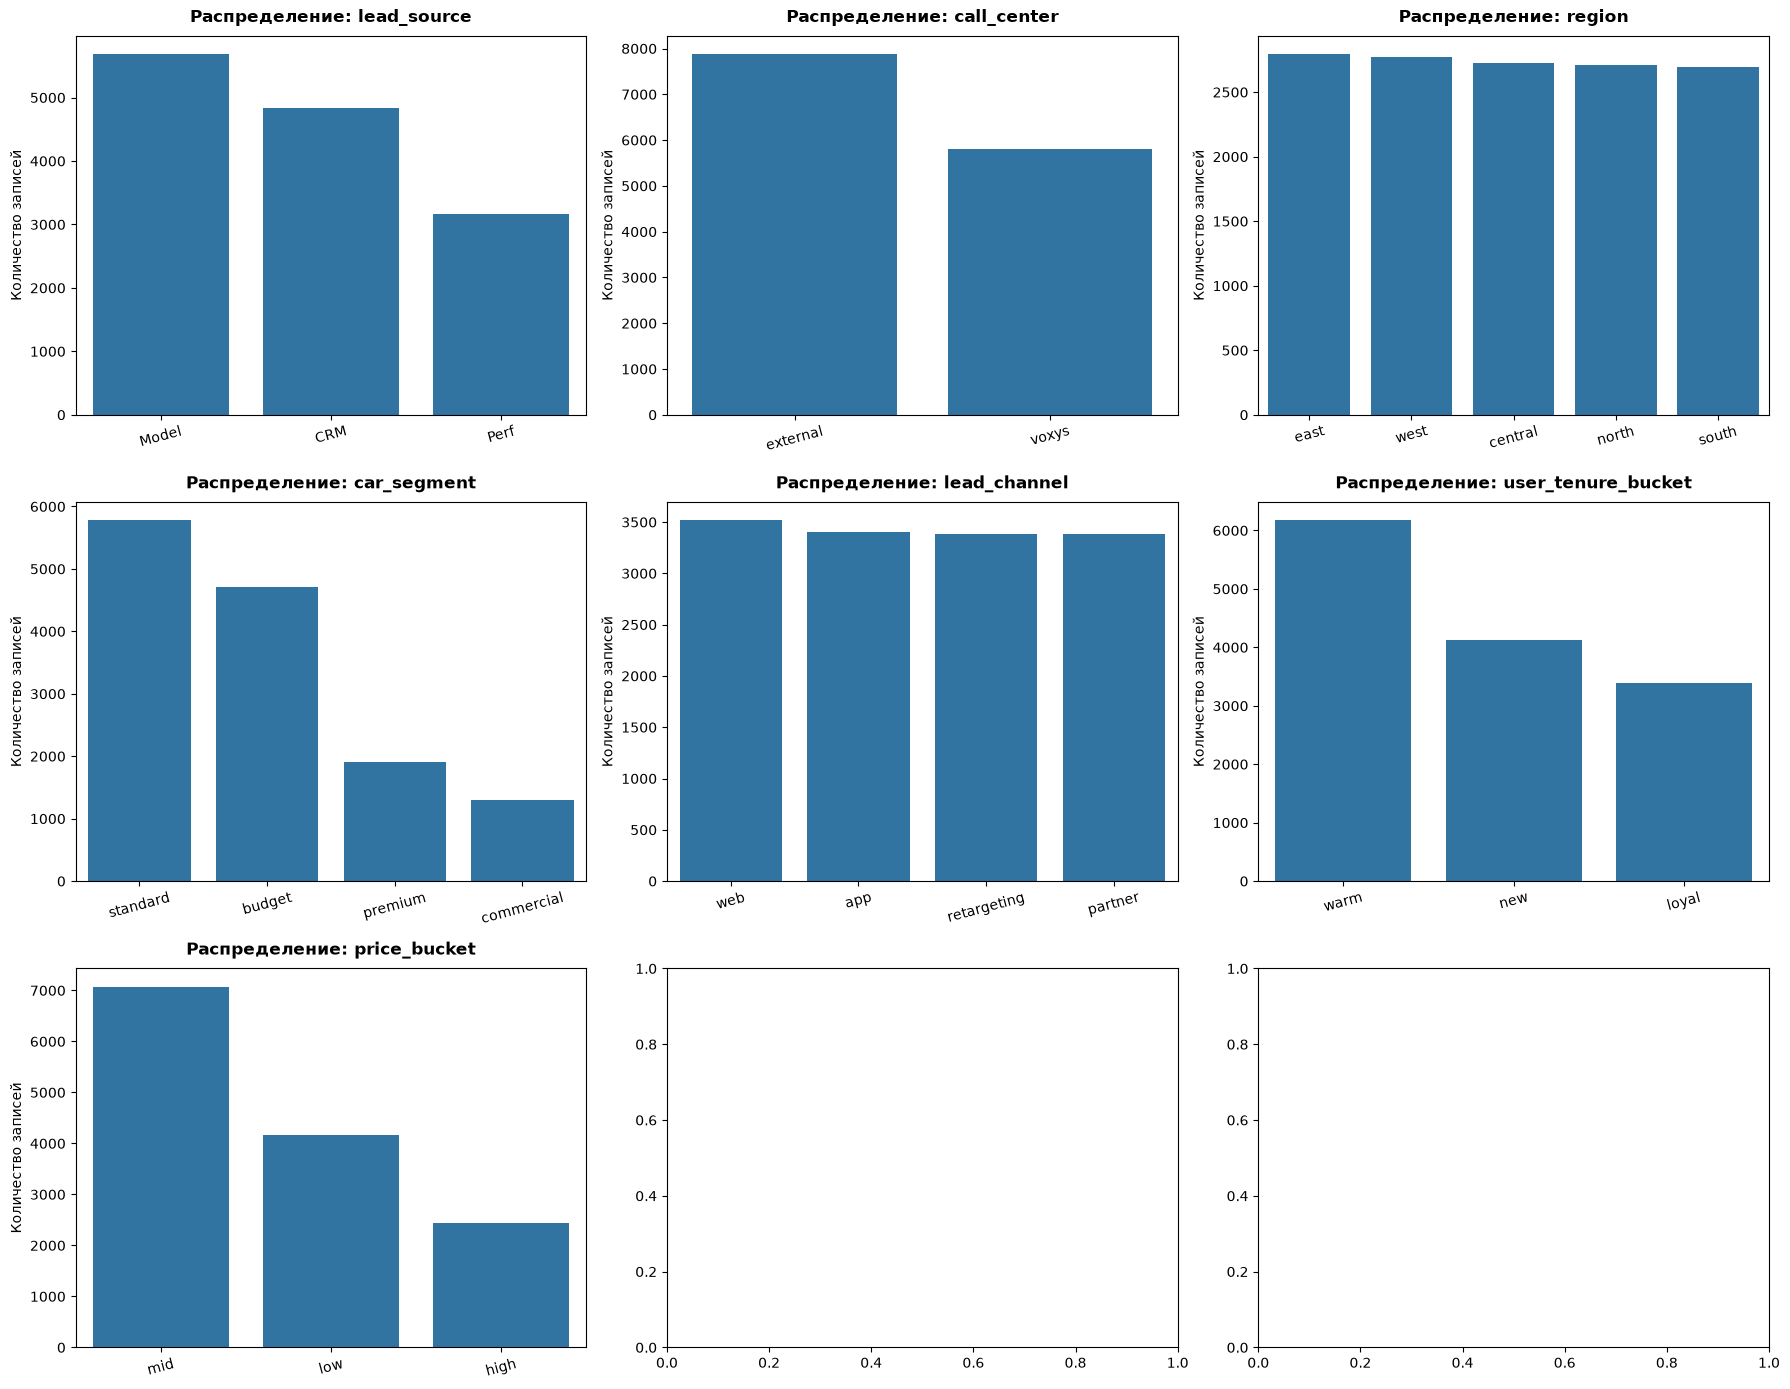

In [66]:
cat_cols = train.select_dtypes(include=["object", "category", "str"]).columns
num = train.select_dtypes(include=["float64", 'int64']).columns

cat_summary = pd.DataFrame({
    "unique_count": train[cat_cols].nunique(),
    "most_frequence": train[cat_cols].mode().iloc[0],
    "missing_pct": train[cat_cols].isnull().mean()*100
}).sort_values(by="unique_count")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
print(cat_cols, len(cat_cols))
for i, col in enumerate(cat_cols[4:]):
    ax = axes[i]

    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, ax=ax)
    ax.set_title(f'Распределение: {col}', weight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Количество записей')
    ax.tick_params(axis='x', rotation=15)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> ### 📊 Анализ распределения категориальных признаков 
> Визуализация распределения категорий позволяет сделать несколько важных выводов о структуре данных:
> 
> * **Высокая однородность и сбалансированность:** Ряд признаков, таких как `region` и `lead_channel`, распределены практически идеально равномерно (uniform distribution). 
> * **Отсутствие проблемы редких категорий (Rare Classes):** Ни в одном из признаков не обнаружено "длинных хвостов" или классов с единичными записями. Даже в относительно скошенных признаках, таких как `car_segment` (класс `commercial`) и `price_bucket` (класс `high`), объем данных в наименьших бакетах превышает 1000+ записей. 
> 
> **Инженерный вывод:** Данные находятся в чистом состоянии и не требуют предварительной предобработки в виде группировки редких классов в категорию `Other` или ручного трешхолдинга. Вся структура категорий сохраняется в исходном виде для передачи в **CatBoostClassifier**, встроенное кодирование которого оптимально раскроет взаимосвязь этих групп с целевой переменной.

## Валидация и баланс классов

In [67]:
X_train, X_val, Y_train, Y_val, val = train_val_split(train)

# Проверка баланса классов
ones_all, zeros_all = train["target"].sum(), len(train) - train["target"].sum()
ones_train, zeros_train = Y_train.sum(), len(Y_train) - Y_train.sum()
ones_val, zeros_val = val["target"].sum(), len(val) - val["target"].sum()


print(f"{'Выборка':<10} | {'Всего объектов':<15} | {'Класс 1 ':<15} | {'Класс 0 ':<15} | {'Доля 1 (%)':<10}")
print("-" * 76)
print(f"{'ALL':<10} | {len(train):<15} | {ones_all:<15} | {zeros_all:<15} | {ones_all / len(train) * 100:.2f}%")
print(f"{'TRAIN':<10} | {len(Y_train):<15} | {ones_train:<15} | {zeros_train:<15} | {ones_train / len(Y_train) * 100:.2f}%")
print(f"{'VAL':<10} | {len(val):<15} | {ones_val:<15} | {zeros_val:<15} | {ones_val / len(val) * 100:.2f}%")


Выборка    | Всего объектов  | Класс 1         | Класс 0         | Доля 1 (%)
----------------------------------------------------------------------------
ALL        | 13694           | 2841            | 10853           | 20.75%
TRAIN      | 10956           | 2277            | 8679            | 20.78%
VAL        | 2738            | 564             | 2174            | 20.60%


> ### ⚖️ Баланс классов и валидация
> 
> * **Соотношение классов:** Пропорция целевого класса к фоновому составляет примерно **1:4** (~21% лидов). Нормальный баланс
> * **Идеальная стратификация:** Доля целевого класса в обучении  и на валидации  практически идентична.
> * **Инженерное решение:** Искусственная балансировка не требуется.

## Построение Baseline модели

In [68]:
_,_,category = features_split(train)
model = CatBoostClassifier(random_state=RANDOM_STATE, thread_count=1)
model.fit(X_train, Y_train, cat_features=category)

Learning rate set to 0.028633
0:	learn: 0.6799791	total: 20.4ms	remaining: 20.4s
1:	learn: 0.6678105	total: 38.6ms	remaining: 19.3s
2:	learn: 0.6566167	total: 54.6ms	remaining: 18.1s
3:	learn: 0.6459288	total: 70.4ms	remaining: 17.5s
4:	learn: 0.6359356	total: 86.1ms	remaining: 17.1s
5:	learn: 0.6263930	total: 101ms	remaining: 16.8s
6:	learn: 0.6174031	total: 119ms	remaining: 16.9s
7:	learn: 0.6087605	total: 136ms	remaining: 16.9s
8:	learn: 0.6008796	total: 154ms	remaining: 17s
9:	learn: 0.5932468	total: 172ms	remaining: 17s
10:	learn: 0.5858379	total: 190ms	remaining: 17.1s
11:	learn: 0.5792911	total: 207ms	remaining: 17s
12:	learn: 0.5734175	total: 222ms	remaining: 16.8s
13:	learn: 0.5676602	total: 239ms	remaining: 16.8s
14:	learn: 0.5618627	total: 256ms	remaining: 16.8s
15:	learn: 0.5569028	total: 272ms	remaining: 16.8s
16:	learn: 0.5519328	total: 289ms	remaining: 16.7s
17:	learn: 0.5471734	total: 307ms	remaining: 16.7s
18:	learn: 0.5429017	total: 324ms	remaining: 16.7s
19:	learn: 0

CatBoostClassifier(random_state=42, thread_count=1)

In [69]:
val["model_score"] = model.predict_proba(X_val)[:,1]
ap = daily_ap(
    df=val,
    y_score_col="model_score",
    y_true_col="target",
    date_col="assignment_date"
)
print(f"daily AP: {ap:.3f}",
     f"AP: {average_precision_score(Y_val, val["model_score"]):.3f}",
      f"Precision: {precision_score(val["target"],model.predict(X_val)):.3f}", sep="\n")

daily AP: 0.519
AP: 0.527
Precision: 0.698


In [70]:
top_features = get_top_importance(model, X_train, top=15)
top_features

,features_names,importance
0,seller_page_views_14d,7.634633
1,seller_page_views_30d,6.903417
2,seller_page_views_7d,6.025178
3,lead_source,3.188783
4,search_views_90d,3.098300
5,photo_swipes_90d,2.459290
6,user_contacts_30d,2.231089
7,user_age_days,2.198889
8,detail_expands_90d,2.012646
9,car_age_years,1.804100


> ### 🏁 Вывод по результатам построения Baseline модели (CatBoost)
> 
> Обучение базового классификатора на исходных статических признаках позволило зафиксировать первичный бенчмарк и определить наиболее информативные направления для дальнейшей работы:
> 
> * **Качество разделения:** Значение Precision на уровне почти 70% подтверждает, что модель даже на базовых агрегатах успешно улавливает ключевые паттерны поведения пользователей.
> * **Анализ важности признаков (Feature Importance):** Встроенный инструмент оценки важности помог наглядно увидеть, какие из исходных статических агрегатов вносят наибольший вклад в предсказание, а какие создают лишний шум для деревьев. Это позволило сузить фокус исследования.
> 
> **Инженерный шаг:** Данная модель принимается за точку отсчета (Benchmark). На основе полученного рейтинга важности был выделен **ТОП-15 признаков**, для которых будет проведён аудит природы пропусков (NaN) и запущен Feature Engineering.

## Первичный Feature Engineering и вторая итерация обучения

In [71]:
top_features = top_features["features_names"]
top_features[15] = "target"
top_col = train[top_features]
top_col.info()

<class 'pandas.DataFrame'>
RangeIndex: 13694 entries, 0 to 13693
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   seller_page_views_14d  13269 non-null  float64
 1   seller_page_views_30d  13262 non-null  float64
 2   seller_page_views_7d   13292 non-null  float64
 3   lead_source            13694 non-null  str    
 4   search_views_90d       13281 non-null  float64
 5   photo_swipes_90d       13287 non-null  float64
 6   user_contacts_30d      13301 non-null  float64
 7   user_age_days          13694 non-null  float64
 8   detail_expands_90d     13301 non-null  float64
 9   car_age_years          13694 non-null  float64
 10  photo_swipes_30d       13282 non-null  float64
 11  search_views_30d       13269 non-null  float64
 12  mileage_km_log         13694 non-null  float64
 13  item_views_14d         13308 non-null  float64
 14  query_refinements_90d  13286 non-null  float64
 15  target       

In [72]:
top_col.isna().sum()

seller_page_views_14d    425
seller_page_views_30d    432
seller_page_views_7d     402
lead_source                0
search_views_90d         413
photo_swipes_90d         407
user_contacts_30d        393
user_age_days              0
detail_expands_90d       393
car_age_years              0
photo_swipes_30d         412
search_views_30d         425
mileage_km_log             0
item_views_14d           386
query_refinements_90d    408
target                     0
dtype: int64

In [73]:
top_col.describe().T

,count,mean,std,min,25%,50%,75%,max
seller_page_views_14d,13269.0,0.929734,1.087984,0.000000,0.000000,0.911259,1.144699,9.794309
seller_page_views_30d,13262.0,1.972345,1.785172,0.000000,0.901586,1.779044,2.919970,13.059028
seller_page_views_7d,13292.0,0.466552,0.729577,0.000000,0.000000,0.000000,0.962152,5.810907
search_views_90d,13281.0,56.158422,32.487257,5.000000,33.000000,49.000000,72.000000,279.000000
photo_swipes_90d,13287.0,46.844434,26.191584,3.000000,28.000000,41.000000,60.000000,223.000000
user_contacts_30d,13301.0,2.446809,2.059083,0.000000,1.000000,2.000000,3.000000,16.000000
user_age_days,13694.0,415.899664,420.696887,1.000000,118.000000,286.000000,572.000000,4088.000000
detail_expands_90d,13301.0,12.747087,7.836186,0.000000,7.000000,11.000000,17.000000,71.000000
car_age_years,13694.0,4.615939,2.717925,0.000000,2.590000,4.520000,6.490750,14.544000
photo_swipes_30d,13282.0,15.481554,9.485460,0.000000,9.000000,13.000000,20.000000,87.000000


> ### 🔍 Вывод по результатам анализа структуры и пропусков (ТОП-15 признаков)
> 
> На основе детального анализа распределений признаков (с помощью метода `.describe()`) и сформированной таблицы пропущенных значений для 15 наиболее важных фич были сделаны следующие выводы:
> 
> * **Распределение по типам данных:** Среди ключевых признаков, на которые сильнее всего опирается модель, подавляющее большинство являются **числовыми**, и только один сильный признак имеет **строковый тип** (`str` / категориальный). Это говорит о том, что для прогнозирования конверсии критически важна именно интенсивность и объёмные показатели действий пользователей.
> * **Природа пропусков (NaN):** Сводная таблица пропусков показывает, что отсутствующие значения в данных фичах имеют не случайную, а выраженную логическую природу. В контексте логов активности отсутствие записи (NaN) фактически означает, что конкретное целевое действие (например, отправка сообщения, просмотр контактов или клик) просто **не совершалось** пользователем вплоть до момента фиксации.
> * **Стратегия:** Исходя из физического смысла данных, при генерации и обработке новых признаков все пропуски безопасно и целесообразно **заменять на ноль (`0`)**. Такая замена полностью сохраняет исходную бизнес-логику (ноль совершенных действий, нулевая длительность сессии), не искажает форму распределений числовых переменных и позволяет древовидным моделям корректно интерпретировать отсутствие активности как самостоятельный и сильный сигнал.

ИДЕИ:
1. **Финансовый сегмент интереса (`item_views * item_price_log`):**  
   Интервальный признак, разделяющий пользователей по фокусу их внимания. Позволяет модели четко разграничить «дешевый» трафик от целевых просмотров в премиум-сегменте.
2. **Плотность вовлеченности:**  
   Рассчитывается как `photo_swipes_90d / user_age_days` и `query_refinements_90d / user_age_days`. Метрика «залипания», отражающая среднее количество микро-взаимодействий пользователя в пересчете на один день «жизни» его аккаунта.
3. **Индекс активности**
4. **Динамика затухания интереса (`30d / 90d`):**  
   Отношение краткосрочной активности к долгосрочной. Сигнализирует о смене паттерна поведения: «остывает» ли пользователь к покупке авто или, наоборот, резко активизировался в последний месяц.
5. **Удельный износ автомобиля (Средний пробег в год):**  
   Формула: `np.expm1(mileage_km_log) / car_age_years`. Физически интерпретируемая бизнес фича, оценивающая интенсивность эксплуатации машины.

In [74]:
#Затухание
s_7d = top_col["seller_page_views_7d"].fillna(0)
s_14d = top_col["seller_page_views_14d"].fillna(0)
s_30d = top_col["seller_page_views_30d"].fillna(0)

train["seller_page_views_7d_14d"] = s_7d / (s_14d + 1)
train["seller_page_views_14d_30d"] = s_14d / (s_30d + 1)
train["seller_page_views_7d_30d"] = s_7d / (s_30d + 1)


/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/2120331635.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["seller_page_views_7d_14d"] = s_7d / (s_14d + 1)
/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/2120331635.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["seller_page_views_14d_30d"] = s_14d / (s_30d + 1)
/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/2120331635.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

In [75]:
# Степень активности пользователя

activity = ["seller_page_views_30d", "search_views_90d", "photo_swipes_30d", "user_contacts_30d", "detail_expands_90d", "item_views_14d", "query_refinements_90d"]

temp_df = train[activity].fillna(0)

train["score_activity"] = np.zeros(shape=(len(train)))

for col in activity:

    train["score_activity"] += temp_df[col] / (temp_df[col].median() + 1)




/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/2250097928.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["score_activity"] = np.zeros(shape=(len(train)))


In [76]:
#Разделение сегментов машин дорогие и др.

item_views = train["item_views_14d"].fillna(0)
train["user_price_segment"] = item_views * train["item_price_log"]
train["user_price_segment"]

/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/3629808200.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["user_price_segment"] = item_views * train["item_price_log"]


0        385.021431
1         64.374110
2        575.722458
3         99.572504
4         95.307198
            ...    
13689    111.560256
13690    163.674524
13691    310.826868
13692    173.615484
13693    124.920330
Name: user_price_segment, Length: 13694, dtype: float64

In [77]:
#Средний пробег
train["mean_mileage"] = np.expm1(train["mileage_km_log"])/(train["car_age_years"] + 1)
train["mean_mileage"]

/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/7123564.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["mean_mileage"] = np.expm1(train["mileage_km_log"])/(train["car_age_years"] + 1)


0         2767.919297
1        12940.605271
2        11269.219765
3        13629.396940
4        18076.045524
             ...     
13689     6502.141489
13690     8535.346797
13691    62947.109044
13692     6154.611683
13693     5345.888754
Name: mean_mileage, Length: 13694, dtype: float64

In [78]:
#Плотность залипания photo_swipes_90d / user_age_days и query_refinements_90d / user_age_days
photo = train["photo_swipes_90d"].fillna(0)
query = train["query_refinements_90d"].fillna(0)
train["swipe_intensity_90d"] = photo / (train["user_age_days"]+1)
train["refine_intensity_90d"] = query / (train["user_age_days"]+1)

new_train = train.copy()

/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/3646353464.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["swipe_intensity_90d"] = photo / (train["user_age_days"]+1)
/var/folders/p_/bwn5v2yn6810z9qwdyhvrt6r0000gn/T/ipykernel_15011/3646353464.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["refine_intensity_90d"] = query / (train["user_age_days"]+1)


###  Обучение второй итерации


In [79]:
X_train, X_val, Y_train, Y_val, val = train_val_split(new_train)


In [80]:
_,_, category = features_split(new_train)
model_features = CatBoostClassifier(random_state=RANDOM_STATE, thread_count=1)
model_features.fit(X_train, Y_train, cat_features=category)

Learning rate set to 0.028633
0:	learn: 0.6806206	total: 18.8ms	remaining: 18.8s
1:	learn: 0.6685229	total: 38.9ms	remaining: 19.4s
2:	learn: 0.6562992	total: 58.7ms	remaining: 19.5s
3:	learn: 0.6450204	total: 75.8ms	remaining: 18.9s
4:	learn: 0.6350377	total: 94.3ms	remaining: 18.8s
5:	learn: 0.6255476	total: 112ms	remaining: 18.6s
6:	learn: 0.6169087	total: 132ms	remaining: 18.7s
7:	learn: 0.6086243	total: 151ms	remaining: 18.7s
8:	learn: 0.6005551	total: 168ms	remaining: 18.5s
9:	learn: 0.5930313	total: 185ms	remaining: 18.3s
10:	learn: 0.5861027	total: 201ms	remaining: 18s
11:	learn: 0.5796647	total: 220ms	remaining: 18.1s
12:	learn: 0.5734369	total: 239ms	remaining: 18.1s
13:	learn: 0.5678957	total: 258ms	remaining: 18.2s
14:	learn: 0.5620372	total: 276ms	remaining: 18.1s
15:	learn: 0.5566414	total: 292ms	remaining: 18s
16:	learn: 0.5520823	total: 312ms	remaining: 18s
17:	learn: 0.5476469	total: 332ms	remaining: 18.1s
18:	learn: 0.5428131	total: 348ms	remaining: 18s
19:	learn: 0.5

CatBoostClassifier(random_state=42, thread_count=1)

In [81]:
val["model_score"] = model_features.predict_proba(X_val)[:,1]
ap = daily_ap(
    df=val,
    y_score_col="model_score",
    y_true_col="target",
    date_col="assignment_date"
)
print(f"daily ap: {ap:.3f}")

daily ap: 0.514


In [82]:
top_col = get_top_importance(model_features, X_train, top=20)
top_col

,features_names,importance
0,seller_page_views_30d,6.449303
1,seller_page_views_14d,6.109120
2,seller_page_views_7d,3.954394
3,lead_source,3.242772
4,search_views_90d,2.977230
5,photo_swipes_90d,2.375254
6,detail_expands_90d,1.947035
7,user_contacts_30d,1.889789
8,seller_page_views_14d_30d,1.862167
9,query_refinements_90d,1.803863


> ### 📊 Вывод по результатам первичного Feature Engineering и обучения модели
> 
> Оценка второй итерации модели, обученной с учётом обработки пропусков и добавления базовых математических взаимодействий, показала следующие результаты:
> 
> * **Динамика метрики:** Локальный скор зафиксировался на уровне **Daily AP = 0.514**. Метрика осталась практически без изменений (незначительное колебание в пределах статистического шума относительно базового `0.519`).
> * **Инженерный инсайт:** Результат наглядно подтвердил гипотезу о том, что статические характеристики профиля и простые линейные комбинации фич быстро упираются в свой логический «потолок».
> * **Влияние фич:** По результатам влияния, видно что модель приняла некоторые из них, но для неё они оказались очевидными.
>
> **Вектор дальнейшего развития:** Переход к агрегации сырых исторических логов из `events.csv`. 

## Инжиниринг поведенческих логов (`events.csv`) и обучение

In [83]:
event = pd.read_csv("../data/events.csv")
event.head()

,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02


In [84]:
event.info()

<class 'pandas.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   lead_id         254705 non-null  str    
 1   user_id         254705 non-null  str    
 2   event_ts        254705 non-null  str    
 3   event_type      254705 non-null  str    
 4   item_price_log  254705 non-null  float64
 5   src_slot        254705 non-null  float64
 6   ctx_seq         254705 non-null  str    
dtypes: float64(2), str(5)
memory usage: 13.6 MB


In [85]:
event.describe()

,item_price_log,src_slot
count,254705.000000,254705.000000
mean,12.916970,12.566373
std,0.605131,6.345974
min,10.490479,1.000000
25%,12.484720,7.000000
50%,12.915912,13.000000
75%,13.331997,18.000000
max,15.299317,25.000000


ИДЕИ:
1. **Активность пользователя** — количество открытий чата.
2. **Разброс цен** — стандартное отклонение и размах цен просмотренных объявлений.
3. **`activity_duration_min`** — чистая длительность сессии на Авито прямо перед назначением обращения.
4. **`unique_slots_count`** — разнообразие источников кликов (из скольких уникальных блоков/рекомендаций юзер открывал авто).
5. **`max_ctx_seq`** — общая глубина сессии (суммарное количество любых действий в логах до лида).

In [86]:
# Создание допольнительных фич из events.csv


event["event_ts"] = pd.to_datetime(event["event_ts"])
new_train["assignment_ts"] = pd.to_datetime(new_train["assignment_ts"])
new_train = event_features(new_train, event).copy()


In [87]:
new_train.head()

,lead_id,user_id,assignment_ts,assignment_date,lead_source,call_center,region,car_segment,lead_channel,user_tenure_bucket,...,user_price_segment,mean_mileage,swipe_intensity_90d,refine_intensity_90d,chat_open_count,price_std,price_spread,activity_duration_min,unique_slots_count,max_ctx_seq
0,lead_f57db09ab39ae3e7,user_0000001,2026-04-22 11:56:00,2026-04-22,CRM,external,west,budget,retargeting,warm,...,385.021431,2767.919297,0.000000,0.214286,2.0,0.120068,0.396249,39846.0,10.0,17.0
1,lead_a6184b8a8165a27b,user_0000002,2026-04-07 14:49:00,2026-04-07,CRM,voxys,north,standard,partner,warm,...,64.374110,12940.605271,0.057692,0.017308,1.0,0.170504,0.422962,33777.0,5.0,5.0
2,lead_229c2a117dbac203,user_0000003,2026-04-12 17:01:00,2026-04-12,Perf,external,north,budget,retargeting,new,...,575.722458,11269.219765,0.594502,0.164948,2.0,0.184553,0.855434,40506.0,15.0,27.0
3,lead_16b19e58042ef905,user_0000005,2026-04-13 21:39:00,2026-04-13,Model,voxys,east,premium,partner,warm,...,99.572504,13629.396940,0.013350,0.002543,0.0,0.131122,0.368056,35440.0,9.0,9.0
4,lead_734c227324978a36,user_0000006,2026-04-12 18:01:00,2026-04-12,CRM,voxys,central,budget,retargeting,warm,...,95.307198,18076.045524,0.027002,0.005587,0.0,0.105336,0.377934,39982.0,10.0,10.0


>### **Результат**
> 
> На основе сырых исторических логов активности (`events.csv`) был успешно реализован блок Feature Engineering. Сгенерирован следующий набор признаков:
>
> 1. **`chat_open_count`** — количество открытий чата (прямой маркер высокой интенции к совершению сделки).
> 2. **`price_std`** и **`price_spread`** — стандартное отклонение и размах логарифмов цен просмотренных объявлений (метрики вариативности бюджета и определенности пользователя с ценовым сегментом).
> 3. **`activity_duration_min`** — чистая длительность сессии на платформе в минутах (фиксирует непрерывное время вовлеченности пользователя до лида).
> 4. **`unique_slots_count`** — разнообразие источников кликов (количество уникальных блоков, рекомендаций и слотов, из которых юзер открывал карточки).
> 5. **`max_ctx_seq`** — общая глубина сессии (суммарный объем абсолютно всех микро-действий пользователя в логах).

In [88]:
X_train, X_val, Y_train, Y_val, val = train_val_split(new_train)

In [89]:
_, _, category = features_split(new_train)
model_event = CatBoostClassifier(random_state=RANDOM_STATE, thread_count=1)
model_event.fit(X_train,Y_train, cat_features=category)

Learning rate set to 0.028633
0:	learn: 0.6800663	total: 24.6ms	remaining: 24.5s
1:	learn: 0.6672814	total: 44.9ms	remaining: 22.4s
2:	learn: 0.6560335	total: 65.3ms	remaining: 21.7s
3:	learn: 0.6450239	total: 83.6ms	remaining: 20.8s
4:	learn: 0.6345170	total: 104ms	remaining: 20.8s
5:	learn: 0.6245613	total: 123ms	remaining: 20.4s
6:	learn: 0.6157470	total: 141ms	remaining: 20s
7:	learn: 0.6071495	total: 160ms	remaining: 19.9s
8:	learn: 0.5985587	total: 180ms	remaining: 19.8s
9:	learn: 0.5910752	total: 198ms	remaining: 19.6s
10:	learn: 0.5832035	total: 217ms	remaining: 19.5s
11:	learn: 0.5764682	total: 236ms	remaining: 19.4s
12:	learn: 0.5702488	total: 254ms	remaining: 19.3s
13:	learn: 0.5638148	total: 274ms	remaining: 19.3s
14:	learn: 0.5579278	total: 293ms	remaining: 19.2s
15:	learn: 0.5523366	total: 310ms	remaining: 19s
16:	learn: 0.5473455	total: 328ms	remaining: 19s
17:	learn: 0.5428219	total: 348ms	remaining: 19s
18:	learn: 0.5383223	total: 365ms	remaining: 18.9s
19:	learn: 0.53

CatBoostClassifier(random_state=42, thread_count=1)

In [90]:
from sklearn.metrics import average_precision_score, precision_score

val["model_score"] = model_event.predict_proba(X_val)[:,1]
ap = daily_ap(
    df=val,
    y_score_col="model_score",
    y_true_col="target",
    date_col="assignment_date"
)
print(f"daily AP: {ap:.3f}\nAP: {average_precision_score(Y_val, val["model_score"]):.3f}\nPrecision: {precision_score(val["target"],model_event.predict(X_val)):.3f}")

daily AP: 0.562
AP: 0.570
Precision: 0.731


> ### Вывод по результатам обучения модели с поведенческими фичами
> 
> Интеграция динамических признаков из логов активности (`events.csv`) обеспечила качественный прорыв и вывела классификатор на принципиально новый уровень точности:
> 
> * **Значительный рост метрик:** Модель достигла уровня **Daily AP = 0.562** и общего **AP = 0.570**, что демонстрирует мощный шаг вперед по сравнению с первоначальным базовым решением (Baseline Daily AP = 0.519). Это доказывает, что поведенческий контекст полностью преодолел возникшее ранее плато.
> * **Высокая бизнес-эффективность:** Метрика **Precision зафиксировалась на отметке 0.731**. Это означает, что более 73% лидов, которые модель классифицирует как потенциально конверсионные, действительно совершают целевое действие.
> * **Валидационная стабильность:** Небольшой разрыв между общим AP (0.570) и посуточным Daily AP (0.562) подтверждает устойчивость модели во времени и отсутствие склонности к переобучению на отдельных днях.
> 
> **Итог:** Разработанный комплекс фич показал отличную предсказательную способность.

## Перебор параметров модели

In [91]:
model_tune = CatBoostClassifier(
    iterations=2000,
    random_state=RANDOM_STATE,
    thread_count=1,
    early_stopping_rounds=100,
    eval_metric="PRAUC",
    cat_features=category
)

param_grid = {
    "depth": [i for i in range(4, 9)],
    "l2_leaf_reg": [1, 3, 5,7, 10],
    'random_strength': [0.0, 0.5, 1.0, 2.0],
    'bagging_temperature': [0.0, 0.2, 0.5, 1.0]
}


search_res = model_tune.randomized_search(
    param_grid,
    X=X_train,
    y=Y_train,
    n_iter=15,
    partition_random_seed=RANDOM_STATE,
    refit=True,
    verbose=False
)
print("Лучшие параметры:", search_res['params'])

val["model_score"] = model_tune.predict_proba(X_val)[:,1]
ap = daily_ap(
    df=val,
    y_score_col="model_score",
    y_true_col="target",
    date_col="assignment_date" 
)
print(f"daily AP: {ap:.3f}\nAP: {average_precision_score(Y_val, val["model_score"]):.3f}\nPrecision: {precision_score(val["target"],model_tune.predict(X_val)):.3f}")

0:	learn: 0.4418700	test: 0.4023655	best: 0.4023655 (0)	total: 23.1ms	remaining: 46.2s
1:	learn: 0.4522421	test: 0.4220229	best: 0.4220229 (1)	total: 43.5ms	remaining: 43.4s
2:	learn: 0.4724404	test: 0.4421109	best: 0.4421109 (2)	total: 63.8ms	remaining: 42.5s
3:	learn: 0.4807894	test: 0.4462041	best: 0.4462041 (3)	total: 86.6ms	remaining: 43.2s
4:	learn: 0.4831151	test: 0.4476359	best: 0.4476359 (4)	total: 107ms	remaining: 42.8s
5:	learn: 0.4939924	test: 0.4593701	best: 0.4593701 (5)	total: 127ms	remaining: 42.1s
6:	learn: 0.5009775	test: 0.4682258	best: 0.4682258 (6)	total: 147ms	remaining: 41.9s
7:	learn: 0.5100206	test: 0.4738719	best: 0.4738719 (7)	total: 166ms	remaining: 41.3s
8:	learn: 0.5121085	test: 0.4739870	best: 0.4739870 (8)	total: 187ms	remaining: 41.3s
9:	learn: 0.5187141	test: 0.4781744	best: 0.4781744 (9)	total: 208ms	remaining: 41.3s
10:	learn: 0.5236640	test: 0.4767192	best: 0.4781744 (9)	total: 228ms	remaining: 41.3s
11:	learn: 0.5254950	test: 0.4785522	best: 0.4785

> ### Вывод по результатам гиперпараметрического тюнинга
> 
> Проведение направленного перебора гиперпараметров позволило найти более сбалансированную конфигурацию модели и выжать из сгенерированных фич максимальный результат:
> 
> * **Оптимальный подбор параметров:** Наилучший результат показала более консервативная сборка: `{'depth': 5, 'l2_leaf_reg': 5, 'bagging_temperature': 0.5, 'random_strength': 1}`. Снижение глубины деревьев до 5 и усиление L2-регуляризации помогли CatBoost эффективнее бороться с шумом в логах.
> * **Максимальный скор:** Модель достигла пиковых значений по целевым метрикам: **Daily AP = 0.571** и общий **AP = 0.579** (чистый прирост относительно прошлой итерации). 
> * **Анализ компромисса (Trade-off):** Метрика Precision незначительно скорректировалась до уровня **0.719** (что по-прежнему является очень высоким и выгодным для бизнеса показателем точности), однако взамен мы получили существенное улучшение качества посуточного ранжирования (Daily AP). Модель стала находить больше целевых лидов, сохраняя уверенность в предсказаниях.
> 
> **Итоговое решение:** Данная конфигурация фиксируется как **финальное решение**. Пайплайн успешно прошёл путь от простейшего базового табличного классификатора (Daily AP = 0.519) до кастомной, глубоко настроенной поведенческой модели (Daily AP = 0.571). Решение готово к финальному инференсу и отправке.

## Создание `submission.csv`

In [92]:
X_test_processed = test.copy()
spv_30 = X_test_processed['seller_page_views_30d'].fillna(0)
spv_14 = X_test_processed['seller_page_views_14d'].fillna(0)
spv_7 = X_test_processed['seller_page_views_7d'].fillna(0)

# Базовые фичи для интенсивностей и сегментов
X_test_processed['seller_page_views_7d_14d'] = spv_7 / (spv_14 + 1)
X_test_processed['seller_page_views_14d_30d'] = spv_14 / (spv_30  + 1)
X_test_processed['seller_page_views_7d_30d'] = spv_7 / (spv_30 + 1) 


activity = ["seller_page_views_30d", "search_views_90d", "photo_swipes_30d", "user_contacts_30d", "detail_expands_90d", "item_views_14d", "query_refinements_90d"]

temp_df = X_test_processed[activity].fillna(0)

X_test_processed["score_activity"] = np.zeros(shape=(len(X_test_processed)))
for col in activity:
    X_test_processed["score_activity"] += temp_df[col] / (temp_df[col].median() + 1)



item_views = X_test_processed["item_views_14d"].fillna(0)
X_test_processed["user_price_segment"] = item_views * X_test_processed["item_price_log"]

X_test_processed["mean_mileage"] = np.expm1(X_test_processed["mileage_km_log"])/(X_test_processed["car_age_years"] + 1)


photo = X_test_processed["photo_swipes_90d"].fillna(0)
query = X_test_processed["query_refinements_90d"].fillna(0)
X_test_processed["swipe_intensity_90d"] = photo / (X_test_processed["user_age_days"]+1)
X_test_processed["refine_intensity_90d"] = query / (X_test_processed["user_age_days"]+1)


X_test_processed["assignment_ts"] = pd.to_datetime(X_test_processed["assignment_ts"])
X_test_processed = event_features(X_test_processed, event)

X_test_final = X_test_processed[X_train.columns]

X_test_processed['score'] = model_tune.predict_proba(X_test_final)[:, 1]
submission = X_test_processed[['lead_id', 'score']]
submission.to_csv('../output/submission.csv', index=False)

print(f"1. Строк в файле: {submission.shape[0]} (Ожидалось: {len(test)})")
print(f"2. Пропусков в финальных скорах: {submission['score'].isna().sum()}")
print(f"3. Непустых поведенческих фич (успешный мерж логов теста): {X_test_processed['max_ctx_seq'].gt(0).sum()} из {len(test)}")
print(f"4. Границы распределения скоров: [{submission['score'].min():.4f} ... {submission['score'].max():.4f}]")

1. Строк в файле: 4306 (Ожидалось: 4306)
2. Пропусков в финальных скорах: 0
3. Непустых поведенческих фич (успешный мерж логов теста): 4303 из 4306
4. Границы распределения скоров: [0.0013 ... 0.9946]


In [93]:
assert list(submission.columns) == ["lead_id", "score"]
assert len(submission) == len(test)
assert submission["lead_id"].is_unique
assert submission["score"].between(0, 1).all()

print("submission.csv is ready")

submission.csv is ready
